In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns

In [3]:
from scipy import sparse
from scipy.stats import entropy, spearmanr, mannwhitneyu, fisher_exact
from scipy.spatial import cKDTree

# H&E image

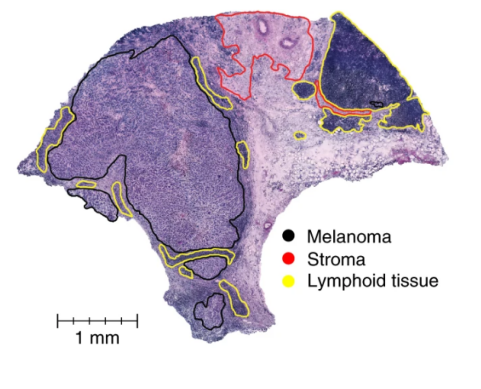

In [4]:
img = mpimg.imread("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/melanoma_rep1.png")

plt.imshow(img)
plt.axis("off")   # hides axes
plt.show()

# Load data (K=4 )

In [40]:
adata = sc.read_h5ad("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/ST_mel1_rep2.h5ad")
adata.var_names_make_unique()

sc.pp.filter_genes(adata, min_counts=11)

adata.layers["counts"] = adata.X
sc.pp.normalize_total(adata)
adata.layers["norm"] = adata.X
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X

adata

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 293 × 10942
    obs: 'array_row', 'array_col', 'array_col_flipped'
    var: 'gene_id', 'ensemble_id', 'n_counts'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts', 'norm', 'lognorm'

In [41]:
SIGNATURES = {
    "Tumor cells (surrounding)": ["CXCL10","WARS1","C1QB","GBP4","CXCL9"],
    "Tumor cells (center)": ["SPP1","HSPB1","ATP1A1","NDRG1","ANXA1"],
    "Stroma": ["MYL9","CFD","DCN","COL3A1","CH507-513H4.5"],
    "Lymphoid": ["LTB","CD79A","MS4A1","CCL21","CD79B"],
}

In [42]:
K=4

## Proportions ($H$)

In [43]:
snmf_proportions = pd.read_csv(f"./K{K}/SNMF_proportions.csv", index_col=0)
snmf_proportions

,V1,V2,V3,V4
7x15,0.273434,0.074859,0.197405,0.454302
7x16,0.214527,0.221338,0.244812,0.319322
7x17,0.113882,0.402639,0.329447,0.154032
7x18,0.105490,0.542102,0.224054,0.128354
8x13,0.096841,0.157762,0.337943,0.407454
...,...,...,...,...
27x18,0.000398,0.508507,0.263692,0.227403
27x19,0.002746,0.511702,0.174788,0.310764
27x20,0.000486,0.306714,0.550300,0.142501
27x21,0.000172,0.046386,0.811832,0.141610


In [44]:
adata.obs = pd.concat([adata.obs, snmf_proportions], axis=1)

## Signatures ($W$)

In [45]:
snmf_signatures = pd.read_csv(f"./K{K}/signatures.csv", index_col=0)
snmf_signatures

,V1,V2,V3,V4
PSME2,2.525698,3.402686,4.120988,15.210364
CUEDC1,0.737316,0.464158,0.175260,0.473928
RPLP1,49.104226,208.518566,89.693294,34.965121
TM9SF3,1.698330,0.774839,1.797160,1.880538
DEF8,1.259931,2.311964,1.620939,1.216029
...,...,...,...,...
MICU3,0.000001,0.330808,0.213525,0.000001
CTAGE5,0.025709,0.181829,0.229819,0.000001
ALPL,0.000001,0.000002,0.411979,0.000001
GPC3,0.000001,0.000002,0.514976,0.000001


In [46]:
adata.var = pd.concat([adata.var, snmf_signatures], axis=1)

## Inverse-dispersion matrix ($\phi$)

In [12]:
phi = pd.read_csv(f"./K{K}/phi.csv", index_col=0)
phi

FileNotFoundError: [Errno 2] No such file or directory: './K4/phi.csv'

In [ ]:
adata.obs["phi"] = phi.mean(axis=1)

## Spatial filtering matrix $S$

In [47]:
TAU = 0.8

In [48]:
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

positions = np.array(adata.obs_names.str.split("x").tolist()).astype(float)

x = positions[:, 0]
y = positions[:, 1]

def mean_value(gamma, x, y, tau):
    gamma = gamma[0] if np.ndim(gamma) else gamma

    # Pairwise squared Euclidean distances
    coords = np.column_stack((x, y))
    D2 = cdist(coords, coords, metric='sqeuclidean')

    # Similarity matrix
    S = np.exp(-gamma * D2)
    S[S < 1e-3] = 0

    # Row normalization
    row_sums = S.sum(axis=1, keepdims=True)
    S = S / row_sums

    # Objective function
    return (np.mean(np.diag(S)) - tau) ** 2

# Optimize gamma
result = minimize(
    mean_value,
    x0=[1.0],
    args=(x, y, TAU),
    method="BFGS"
)

gamma = result.x[0]

# Compute final normalized similarity matrix
coords = np.column_stack((x, y))
D2 = cdist(coords, coords, metric='sqeuclidean')

S = np.exp(-gamma * D2)
S[S < 1e-3] = 0

row_sums = S.sum(axis=1, keepdims=True)
S = S / row_sums

## Inferred matrix $V$

In [50]:
V = (snmf_signatures.values @ snmf_proportions.values.T @ S).T
adata.X = np.round(V)

adata.layers["inferred_counts"] = adata.X
sc.pp.normalize_total(adata)
adata.layers["inferred_norm"] = adata.X
sc.pp.log1p(adata)
adata.layers["inferred_lognorm"] = adata.X

# Functions

In [54]:
def valid_genes(genes):
    return [g for g in genes if g in adata.var_names]

def add_expr_score(genes, key):
    genes = valid_genes(genes)
    X = adata[:, genes].X
    vals = X.mean(axis=1)
    adata.obs[key] = vals
    return genes

def add_phi_score(genes, key):
    genes = [g for g in genes if g in phi.columns]
    adata.obs[key] = phi[genes].mean(axis=1)
    return genes

def zscore(s):
    s = pd.Series(s).astype(float)
    sd = s.std()
    return (s - s.mean()) / (sd if sd and not np.isnan(sd) else 1.0)

def compare_by_mask(value_key, mask):
    x = adata.obs.loc[mask, value_key].dropna()
    y = adata.obs.loc[~mask, value_key].dropna()
    p = mannwhitneyu(x, y, alternative="two-sided").pvalue if len(x) and len(y) else np.nan
    return pd.Series({
        "feature": value_key,
        "in_median": x.median(),
        "out_median": y.median(),
        "p": p,
        "n_in": len(x),
        "n_other": len(y),
    })

# Annotation

In [55]:
import numpy as np

snmf_z = (snmf_signatures - snmf_signatures.mean(axis=0)) / snmf_signatures.std(axis=0)

score_table = pd.DataFrame(index=SIGNATURES.keys(),
                           columns=snmf_z.columns,
                           dtype=float)

for comp in snmf_z.columns:
    for celltype, markers in SIGNATURES.items():
        valid = [g for g in markers if g in snmf_z.index]
        if len(valid) > 0:
            score_table.loc[celltype, comp] = (
                snmf_z.loc[valid, comp].mean() - snmf_z[comp].mean()
            )
        else:
            score_table.loc[celltype, comp] = -np.inf

# --------------------------------------------------
# 2️⃣ Annotation function
# --------------------------------------------------
def unique_assignment(score_table, threshold=0.2):
    
    # For each component, sort cell types by descending score
    ranked = {
        comp: score_table[comp].sort_values(ascending=False).index.tolist()
        for comp in score_table.columns
    }
    
    assigned_celltypes = set()
    final_assignment = {}
    
    # Sort components by their BEST score (descending)
    components_order = sorted(
        score_table.columns,
        key=lambda c: score_table[c].max(),
        reverse=True
    )
    
    for comp in components_order:
        for celltype in ranked[comp]:
            
            if score_table.loc[celltype, comp] < threshold:
                final_assignment[comp] = "ambiguous"
                break
            
            if celltype not in assigned_celltypes:
                final_assignment[comp] = celltype
                assigned_celltypes.add(celltype)
                break
        else:
            final_assignment[comp] = "ambiguous"
    
    return pd.Series(final_assignment)

# --------------------------------------------------
# 3️⃣ Apply to all components
# --------------------------------------------------
annotation = unique_assignment(score_table)

print(annotation)

V1         Tumor cells (center)
V2                       Stroma
V4    Tumor cells (surrounding)
V3                     Lymphoid
dtype: object


In [56]:
N_TOP_GENES = 5

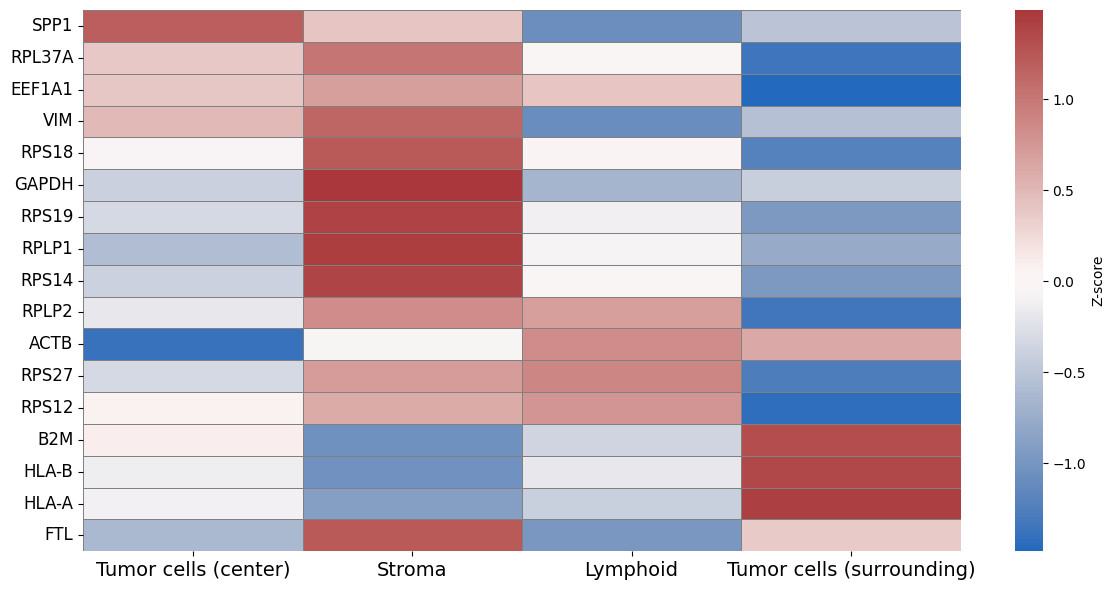

In [57]:
top_genes_ordered = []
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    top_genes_ordered.extend([g for g in top_genes if g not in top_genes_ordered])

# Subset and reorder genes
snmf_top = snmf_signatures.loc[top_genes_ordered]

# ----- 2️⃣ Scale genes (row-wise z-score) -----
snmf_scaled = snmf_top.sub(snmf_top.mean(axis=1), axis=0).div(snmf_top.std(axis=1), axis=0)

# ----- 3️⃣ Fancy heatmap with Seaborn -----
plt.figure(figsize=(12, max(6, len(top_genes_ordered) * 0.25)))

# sns.set_style("white")
# sns.set_context("talk")

# Optionally, order components by annotation or clustering
sns.heatmap(
    snmf_scaled,
    cmap="vlag",          # diverging colormap for z-scores
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Z-score"},
    xticklabels=[annotation.get(c, c) for c in snmf_scaled.columns],
    yticklabels=snmf_scaled.index
)

plt.xticks(fontsize=14)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(f"plots/K{K}_top_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_top_genes_heatmap.pdf", dpi=300)
plt.show()

In [58]:
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    print(f"{annotation[comp]} variance: {snmf_scaled.loc[top_genes,comp].var()}")
    print(f"{annotation[comp]} range: {snmf_scaled.loc[top_genes,comp].max() - snmf_scaled.loc[top_genes,comp].min()}")
    print(f"{annotation[comp]} mean: {snmf_scaled.loc[top_genes,comp].mean()}")
    print()

Tumor cells (center) variance: 0.19959886808967836
Tumor cells (center) range: 1.2367052406727281
Tumor cells (center) mean: 0.481161724315296

Stroma variance: 0.009766503642311358
Stroma range: 0.2642805985263563
Stroma mean: 1.3877875551355205

Lymphoid variance: 0.03582387367922091
Lymphoid range: 0.47849818584548076
Lymphoid mean: 0.7150380862107233

Tumor cells (surrounding) variance: 0.24064331194166044
Tumor cells (surrounding) range: 1.0520187225508262
Tumor cells (surrounding) mean: 1.018346050073736



In [59]:
adata.obs.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.obs.columns]
adata.var.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.var.columns]

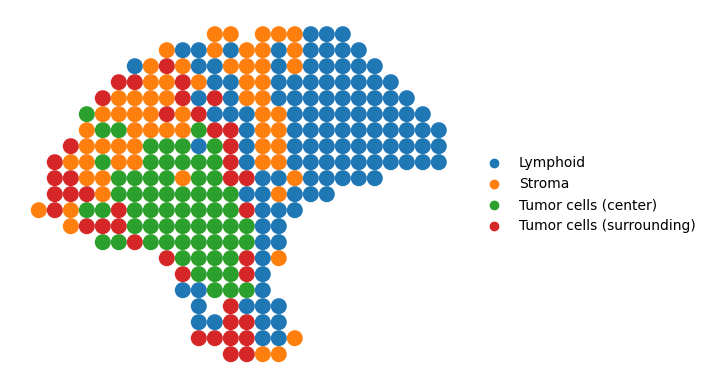

In [60]:
adata.obs["snmf_component"] = adata.obs[[annotation[c] for c in snmf_signatures.columns]].idxmax(axis=1)
sc.pl.spatial(adata, color="snmf_component", spot_size=1, frameon=False, title="", show=False)
plt.savefig(f"plots/K{K}_clustering.png", dpi=300)
plt.savefig(f"plots/K{K}_clustering.pdf", dpi=300)
plt.show()

<Figure size 1400x600 with 0 Axes>

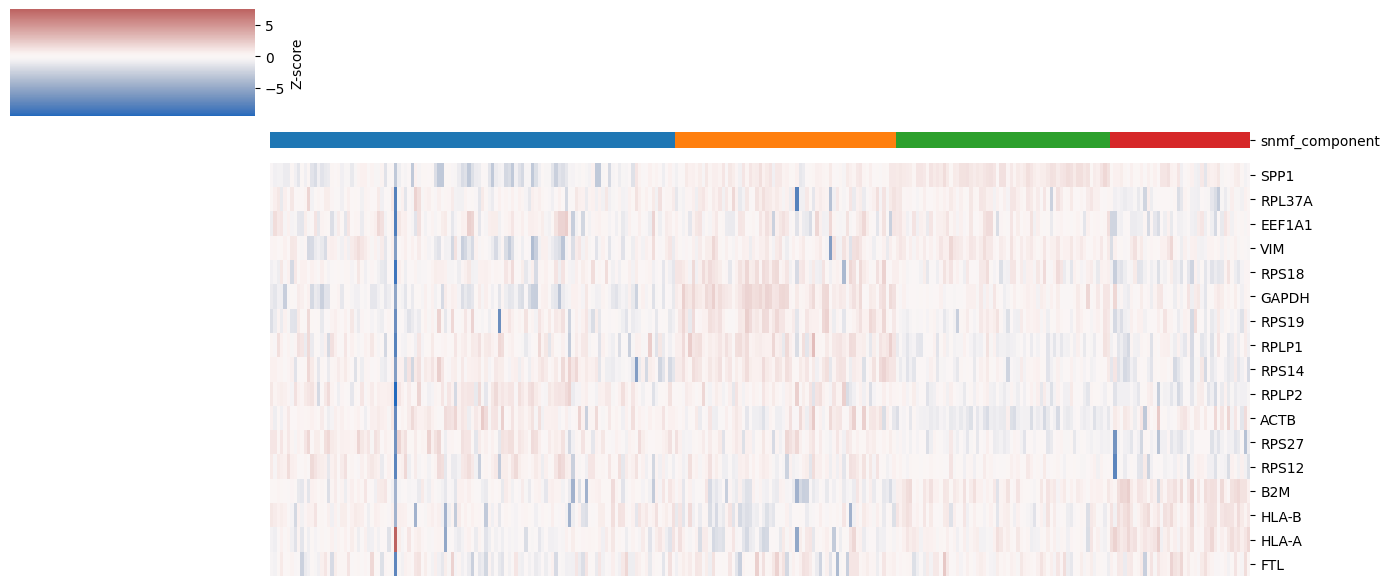

In [62]:
expr = pd.DataFrame(
    adata[:, top_genes_ordered].layers["lognorm"].toarray(),
    index=adata.obs_names,
    columns=top_genes_ordered
).T

spot_order = adata.obs[adata.obs["snmf_component"] != "ambiguous"].sort_values("snmf_component").index
expr = expr[spot_order]

expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1), axis=0)

cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))

col_colors = adata.obs["snmf_component"].map(lut)

plt.figure(figsize=(14, max(6, len(top_genes_ordered)*0.25)))

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(top_genes_ordered)*0.25)),
    cbar_kws={"label": "Z-score"}
)

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

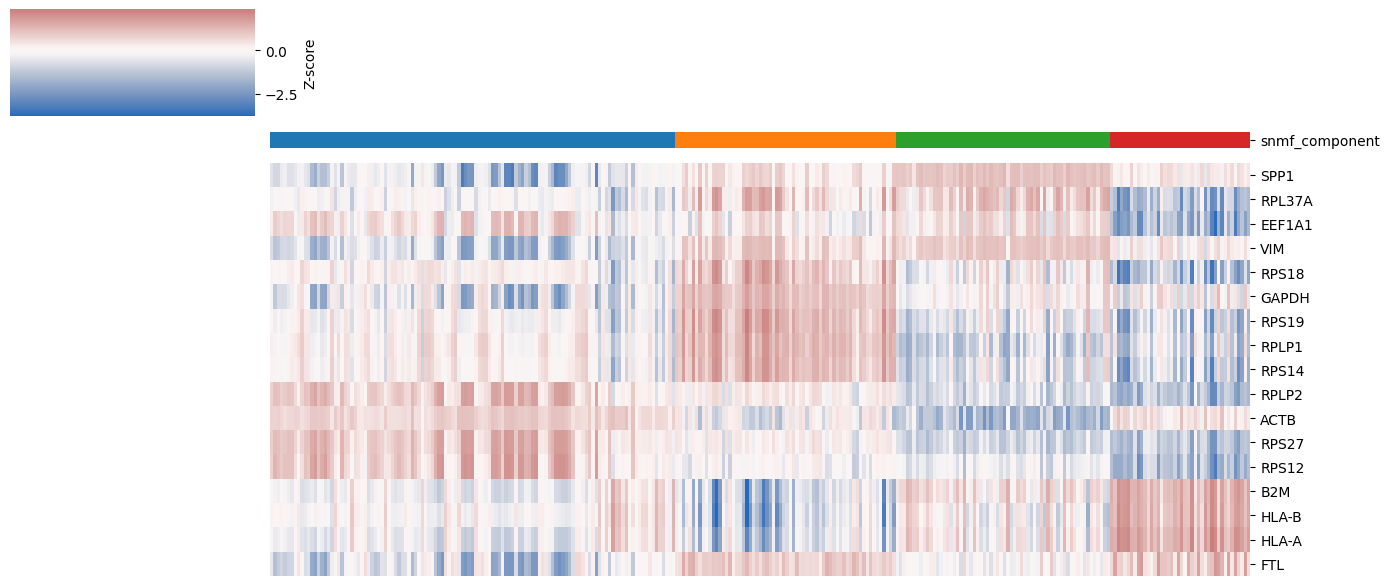

In [63]:
expr = pd.DataFrame(
    adata[:, top_genes_ordered].layers["inferred_lognorm"].toarray(),
    index=adata.obs_names,
    columns=top_genes_ordered
).T

spot_order = adata.obs[adata.obs["snmf_component"] != "ambiguous"].sort_values("snmf_component").index
expr = expr[spot_order]

expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1), axis=0)

cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))

col_colors = adata.obs["snmf_component"].map(lut)

plt.figure(figsize=(14, max(6, len(top_genes_ordered)*0.25)))

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(top_genes_ordered)*0.25)),
    cbar_kws={"label": "Z-score"}
)

plt.tight_layout()
plt.show()

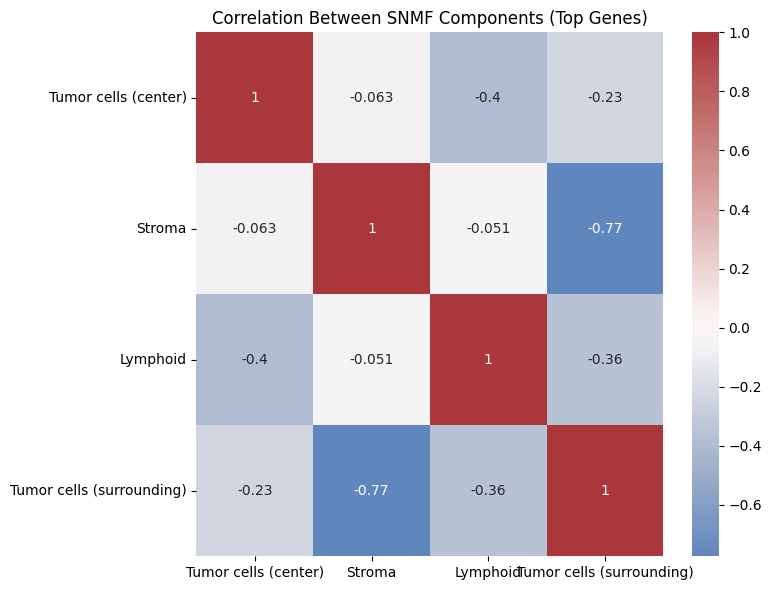

In [65]:
corr_matrix = snmf_scaled.corr()
labels = [annotation.get(c, c) for c in snmf_scaled.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="vlag", center=0)
plt.title("Correlation Between SNMF Components (Top Genes)")

plt.tight_layout()
plt.savefig(f"plots/K{K}top_genes_corr.png", dpi=300)
plt.savefig(f"plots/K{K}top_genes_corr.pdf", dpi=300)
plt.show()

# Proportions

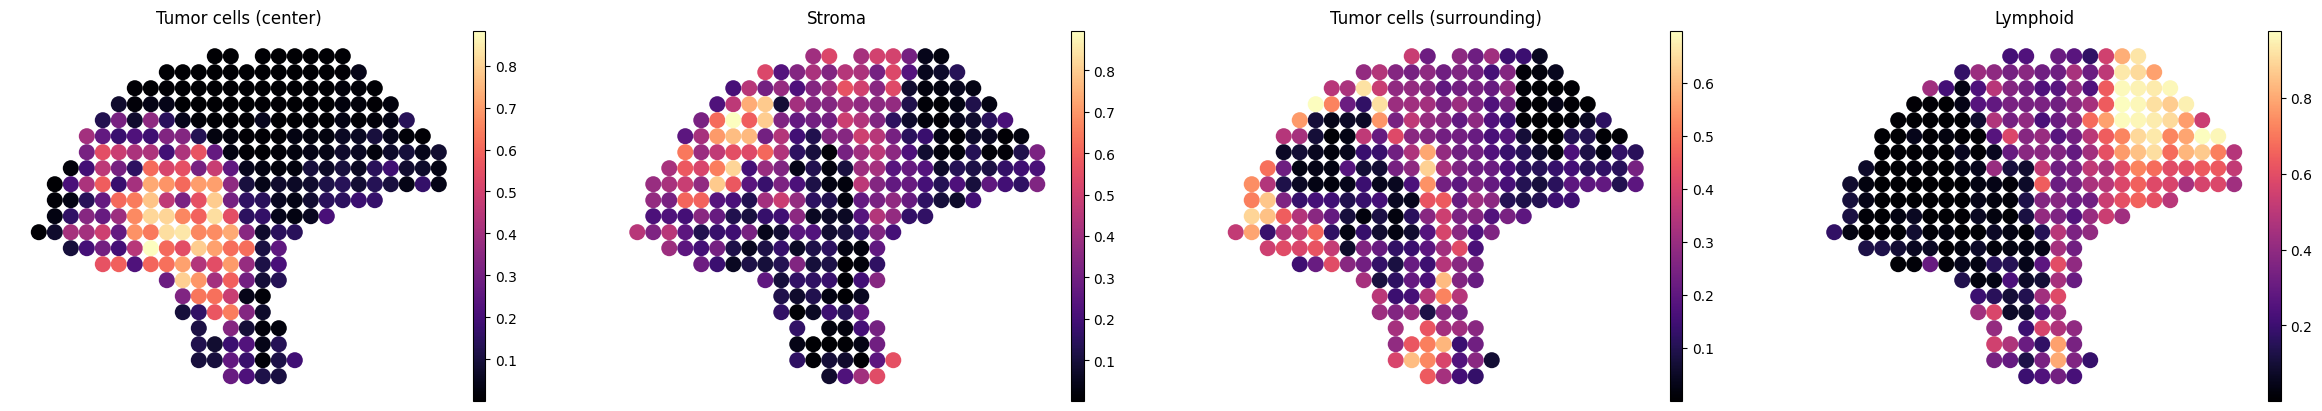

/tmp/ipykernel_2409381/1711416709.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [66]:
colors = annotation.unique().tolist()

fig = sc.pl.spatial(
    adata,
    color=colors,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(colors),
    return_fig=True,
    show=True
)

# Adjust spacing (important when many panels)
fig.tight_layout()

# Save in both formats
fig.savefig(f"plots/K{K}_spatial_plot.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_spatial_plot.pdf", bbox_inches="tight")

plt.close(fig)

# Spatial autocorrelation for each cell type

In [67]:
import squidpy as sq

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [70]:
sq.gr.spatial_neighbors(
    adata,
    spatial_key="spatial",
    coord_type="generic"
)

# compute Moran's I for every cell-type proportion
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    genes=SIGNATURES.keys(),
    attr="obs",
    n_perms=1000
)

# results
moran_df = adata.uns["moranI"].copy()
moran_df = moran_df.sort_values("I", ascending=False)

print(moran_df)

100%|███████████████████████████████████| 1000/1000 [00:00<00:00, 2159.00/s]


                                  I  pval_norm  var_norm  pval_z_sim  \
Lymphoid                   0.861518        0.0  0.001012         0.0   
Tumor cells (center)       0.786226        0.0  0.001012         0.0   
Stroma                     0.663883        0.0  0.001012         0.0   
Tumor cells (surrounding)  0.557482        0.0  0.001012         0.0   

                           pval_sim   var_sim  pval_norm_fdr_bh  \
Lymphoid                   0.000999  0.003068               0.0   
Tumor cells (center)       0.000999  0.002724               0.0   
Stroma                     0.000999  0.002350               0.0   
Tumor cells (surrounding)  0.000999  0.001886               0.0   

                           pval_z_sim_fdr_bh  pval_sim_fdr_bh  
Lymphoid                                 0.0         0.000999  
Tumor cells (center)                     0.0         0.000999  
Stroma                                   0.0         0.000999  
Tumor cells (surrounding)                0.0   

/tmp/ipykernel_2409381/3324005579.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


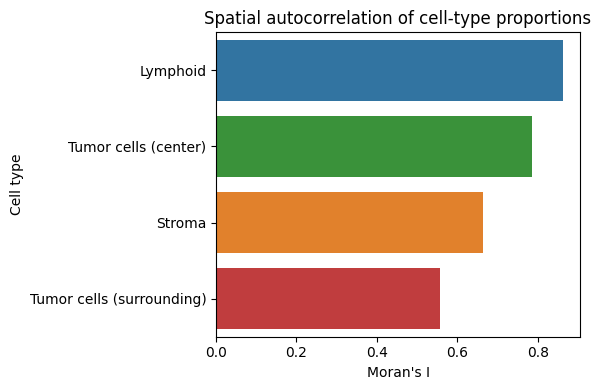

In [72]:
cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))
bar_colors = [lut[ct] for ct in moran_df.index]

plt.figure(figsize=(6, max(4, 0.3 * len(moran_df))))
sns.barplot(
    data=moran_df.reset_index(),
    y="index",
    x="I",
    palette=bar_colors
)
plt.xlabel("Moran's I")
plt.ylabel("Cell type")
plt.title("Spatial autocorrelation of cell-type proportions")
plt.tight_layout()
plt.show()

# $\phi$ enrichment at component boundaries

In [ ]:
coords = adata.obs[["array_row", "array_col"]].to_numpy() if {"array_row", "array_col"}.issubset(adata.obs.columns) else adata.obsm["spatial"]
tree = cKDTree(coords)
_, nn = tree.query(coords, k=min(7, adata.n_obs))

dominant = adata.obs["snmf_component"].astype(str).to_numpy()
P = snmf_proportions.to_numpy()

boundary_score = []
prop_gradient = []

for i, neigh in enumerate(nn):
    neigh = [j for j in neigh if j != i]
    boundary_score.append(np.mean(dominant[neigh] != dominant[i]))
    prop_gradient.append(np.mean(np.abs(P[neigh] - P[i]).sum(axis=1) / 2))

adata.obs["component_boundary_score"] = boundary_score
adata.obs["component_prop_gradient"] = prop_gradient

boundary_mask = adata.obs["component_boundary_score"] > 0
print(compare_by_mask("phi", boundary_mask))
print("rho boundary vs global phi:", spearmanr(adata.obs["component_boundary_score"], adata.obs["phi"]))
print("rho prop-gradient vs global phi:", spearmanr(adata.obs["component_prop_gradient"], adata.obs["phi"]))

sc.pl.spatial(
    adata,
    color=["snmf_component", "component_boundary_score", "phi"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=3,
    show=False,
)
plt.savefig(f"K{K}_boundary_dispersion.png", dpi=300, bbox_inches="tight")
plt.show()

# Antigen-presentation heterogeneity in tumor-dominant spots

In [73]:
ANTIGEN_GENES = ["B2M", "HLA-A", "HLA-B", "HLA-C", "TAP1", "TAP2", "PSMB8", "PSMB9", "NLRC5"]

add_expr_score(ANTIGEN_GENES, "antigen_expr")
add_phi_score(ANTIGEN_GENES, "antigen_phi")

TUMOR_COMPONENTS = [c for c in SIGNATURES if "Tumor" in c]
adata.obs["tumor_score"] = snmf_proportions.obs[TUMOR_COMPONENTS].sum(axis=1) if TUMOR_COMPONENTS else 1.0
tumor_mask = adata.obs["tumor_score"] >= adata.obs["tumor_score"].quantile(0.75)

print(compare_by_mask("antigen_expr", tumor_mask))
print(compare_by_mask("antigen_phi", tumor_mask))
print("rho tumor score vs antigen phi:", spearmanr(adata.obs["tumor_score"], adata.obs["antigen_phi"]))

sc.pl.spatial(
    adata,
    color=["tumor_score", "antigen_expr", "antigen_phi"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=3,
    show=False,
)
plt.savefig(f"K{K}_antigen_presentation_tumor.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'phi' is not defined

# Transition area

In [74]:
TRANSITION_AREA_EXPRESSED_GENES = ["FTL","B2M","APOE","HLA-A","HLA-B","HLA-C"]

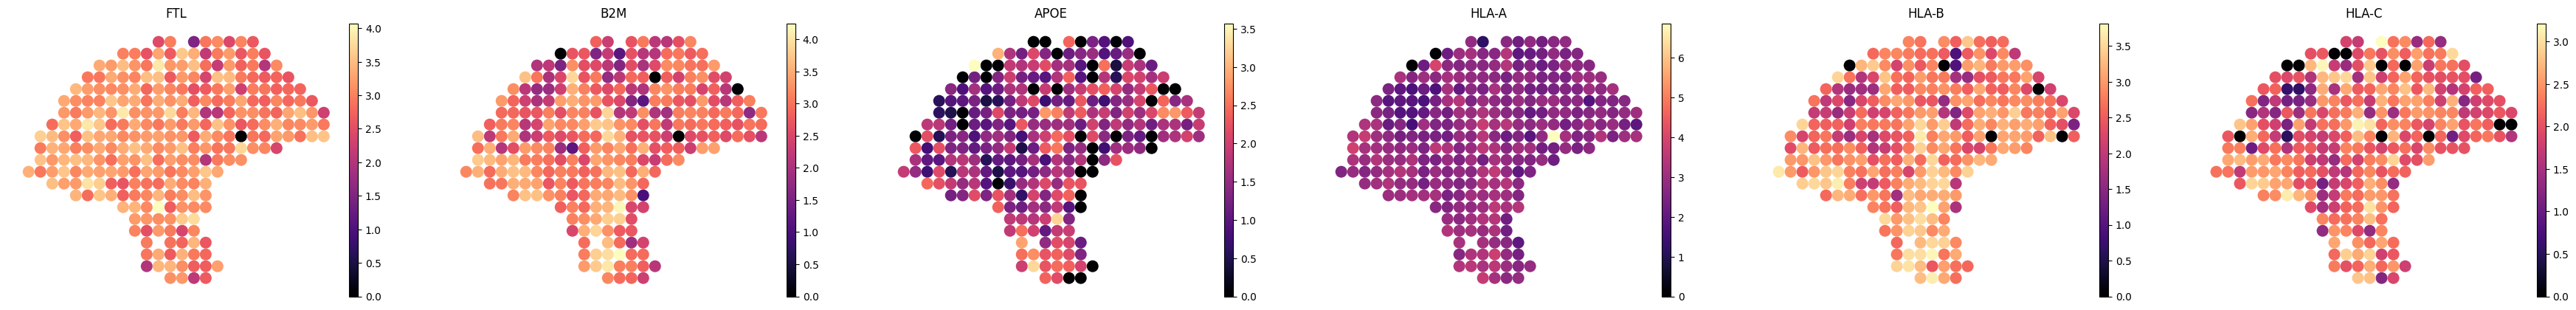

/tmp/ipykernel_2409381/2025489902.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [76]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True,
    layer="lognorm",
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_transition_genes_spatial_gt.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_genes_spatial_gt.pdf", bbox_inches="tight")

plt.close(fig)

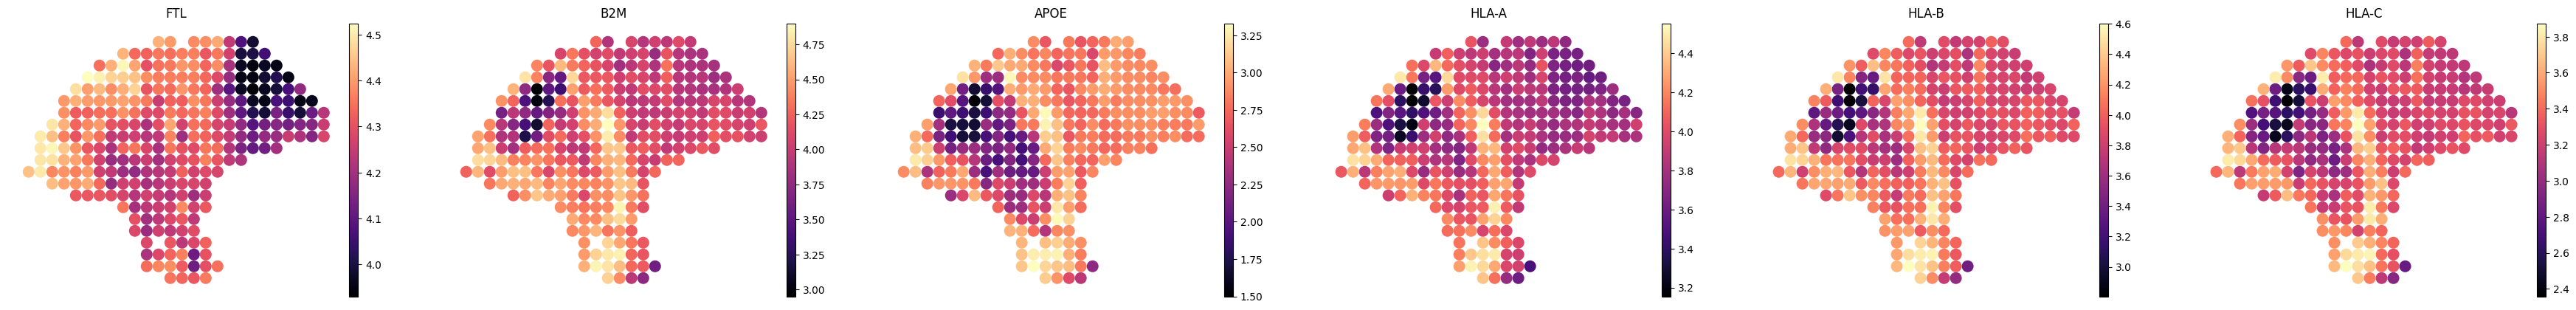

/tmp/ipykernel_2409381/2385037767.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [75]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_transition_genes_spatial_inferred.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_genes_spatial_inferred.pdf", bbox_inches="tight")

plt.close(fig)

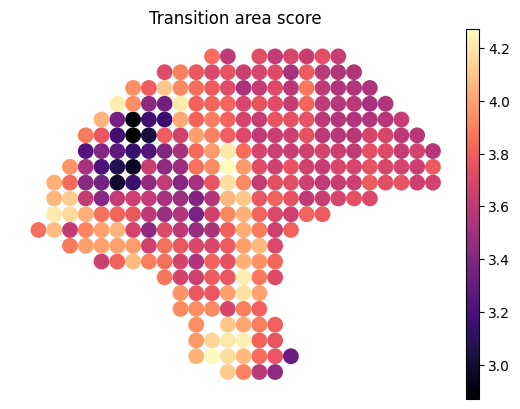

In [77]:
add_expr_score(TRANSITION_AREA_EXPRESSED_GENES, "transition_area_score")

# Plot single spatial score
fig = sc.pl.spatial(
    adata,
    color="transition_area_score",
    spot_size=1,
    frameon=False,
    cmap="magma",
    title="Transition area score",
    return_fig=True,
    show=True
)

# Optional: resize figure for better visibility
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save both PNG and PDF
fig.savefig(f"plots/K{K}_transition_area_score_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_score_spatial.pdf", bbox_inches="tight")

plt.close(fig)

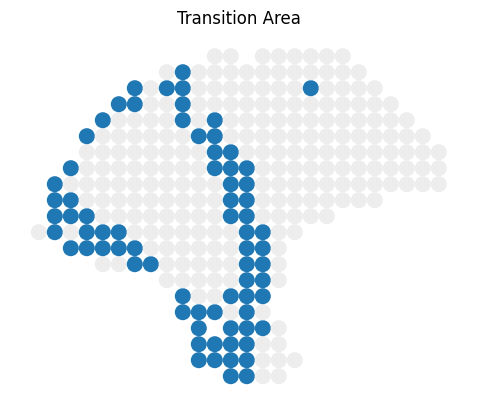

In [78]:
adata.obs["is_in_transition_area"] = np.where(
    adata.obs["transition_area_score"] > adata.obs["transition_area_score"].quantile(0.75),
    "in_transition",
    "out_of_transition"  # use a string instead of None
)

# Optional: make "out_of_transition" white
palette = {
    "in_transition": sns.color_palette("tab20")[0],
    "out_of_transition": "#ededed"
}

fig = sc.pl.spatial(
    adata,
    color="is_in_transition_area",
    spot_size=1,
    frameon=False,
    palette=palette,
    legend_loc="none",
    title="Transition Area",
    return_fig=True,
    show=True
)

# Optional: resize
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save figure
fig.savefig(f"plots/K{K}_transition_area_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_spatial.pdf", bbox_inches="tight")

plt.close(fig)

In [89]:
for component in SIGNATURES.keys():
    rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition",component].values, adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","transition_area_score"].values)
    print(f"Spearman correlation between '{component}' component and transition area score: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between 'Tumor cells (surrounding)' component and transition area score: 0.8352 (pval 0.0000)
Spearman correlation between 'Tumor cells (center)' component and transition area score: 0.0035 (pval 0.9762)
Spearman correlation between 'Stroma' component and transition area score: -0.3451 (pval 0.0028)
Spearman correlation between 'Lymphoid' component and transition area score: -0.2017 (pval 0.0871)


In [84]:
from scipy.stats import entropy

adata.obs["entropy"] = entropy(snmf_proportions, axis=1)
rho, pval = spearmanr(adata.obs["entropy"].values, adata.obs["transition_area_score"].values)
print(f"Spearman correlation between proportions entropy and transition area: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between proportions entropy and transition area: 0.4420 (pval 0.0000)


In [86]:
add_phi_score(TRANSITION_AREA_EXPRESSED_GENES, "transition_phi")

transition_mask = adata.obs["is_in_transition_area"].astype(str).eq("in_transition")

print(compare_by_mask("transition_phi", transition_mask))
print("rho expr-disp:", spearmanr(adata.obs["transition_area_score"], adata.obs["transition_phi"]))

sns.scatterplot(
    data=adata.obs,
    x="transition_area_score",
    y="transition_phi",
    hue="is_in_transition_area",
)
plt.tight_layout()
plt.savefig(f"plots/K{K}_transition_score_vs_dispersion.png", dpi=300)
plt.show()

NameError: name 'phi' is not defined

# Malignant state axis: melanocytic vs invasive/stress

In [30]:
MELANOCYTIC_GENES = ["MLANA", "PMEL", "TYR", "TYRP1", "DCT", "MITF", "SOX10"]
INVASIVE_STRESS_GENES = ["AXL", "VIM", "SPP1", "ANXA1", "NDRG1", "HSPB1", "ITGA3", "NGFR", "FN1"]

add_expr_score(MELANOCYTIC_GENES, "melanocytic_expr")
add_phi_score(MELANOCYTIC_GENES, "melanocytic_phi")

add_expr_score(INVASIVE_STRESS_GENES, "invasive_stress_expr")
add_phi_score(INVASIVE_STRESS_GENES, "invasive_stress_phi")

adata.obs["invasive_melanocytic_axis"] = zscore(adata.obs["invasive_stress_expr"]) - zscore(adata.obs["melanocytic_expr"])
adata.obs["state_dispersion_axis"] = zscore(adata.obs["invasive_stress_phi"]) - zscore(adata.obs["melanocytic_phi"])

print("rho state axis vs transition:", spearmanr(adata.obs["invasive_melanocytic_axis"], adata.obs["transition_expr"]))
print("rho state axis vs dispersion axis:", spearmanr(adata.obs["invasive_melanocytic_axis"], adata.obs["state_dispersion_axis"]))

sc.pl.spatial(
    adata,
    color=["melanocytic_expr", "invasive_stress_expr", "invasive_melanocytic_axis", "state_dispersion_axis"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=4,
    show=False,
)
plt.savefig(f"K{K}_malignant_state_axis.png", dpi=300, bbox_inches="tight")
plt.show()

KeyError: "Values [np.str_('TYRP1')], from [np.str_('MLANA'), np.str_('PMEL'), np.str_('TYR'), np.str_('TYRP1'), np.str_('DCT'), np.str_('MITF'), np.str_('SOX10')], are not valid obs/ var names or indices."

# Lymphoid niche validation

In [ ]:
LYMPHOID_PANELS = {
    "b_cell": ["MS4A1", "CD79A", "CD79B", "BANK1"],
    "t_cell": ["CD3D", "CD3E", "CD2", "TRAC", "IL7R"],
    "cytotoxic": ["NKG7", "GZMB", "PRF1", "GNLY"],
    "myeloid": ["C1QA", "C1QB", "APOE", "LST1", "TYROBP"],
    "lymphoid_structure": ["LTB", "CCL19", "CCL21", "CXCL13"],
}

for panel, genes in LYMPHOID_PANELS.items():
    add_expr_score(genes, f"{panel}_expr")
    add_disp_score(genes, f"{panel}_phi")

LYMPHOID_COMPONENTS = [c for c in SIGNATURES if "Lymphoid" in c]
adata.obs["lymphoid_component_score"] = adata.obs[LYMPHOID_COMPONENTS].sum(axis=1) if LYMPHOID_COMPONENTS else adata.obs["b_cell_expr"]
lymphoid_mask = adata.obs["lymphoid_component_score"] >= adata.obs["lymphoid_component_score"].quantile(0.75)

summary = []
for panel in LYMPHOID_PANELS:
    summary.append(compare_by_mask(f"{panel}_expr", lymphoid_mask))
    summary.append(compare_by_mask(f"{panel}_dispersion", lymphoid_mask))
summary = pd.DataFrame(summary)
display(summary)

sc.pl.spatial(
    adata,
    color=["lymphoid_component_score", "b_cell_expr", "t_cell_expr", "cytotoxic_expr", "myeloid_expr"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=5,
    show=False,
)
plt.savefig(f"K{K}_lymphoid_niche_expression.png", dpi=300, bbox_inches="tight")
plt.show()

# Dispersion-weighted marker discovery

In [ ]:
phi_weighted_markers = {}

for comp, obs_col in COMPONENT_OBS_COL.items():
    common = snmf_signatures.index.intersection(disp_spot_gene.columns)
    high = adata.obs[obs_col] >= adata.obs[obs_col].quantile(0.75)
    low = adata.obs[obs_col] <= adata.obs[obs_col].quantile(0.25)

    sig = snmf_signatures.loc[common, comp]
    high_disp = disp_spot_gene.loc[high, common].mean(axis=0)
    low_disp = disp_spot_gene.loc[low, common].mean(axis=0)
    delta_disp = high_disp - low_disp

    tbl = pd.DataFrame({
        "gene": common,
        "component": obs_col,
        "signature_loading": sig.values,
        "mean_disp_high_component": high_disp.values,
        "mean_disp_low_component": low_disp.values,
        "delta_dispersion": delta_disp.values,
    }).set_index("gene")

    tbl["dispersion_weighted_score"] = zscore(tbl["signature_loading"]) + zscore(tbl["delta_dispersion"])
    tbl = tbl.sort_values("dispersion_weighted_score", ascending=False)

    phi_weighted_markers[obs_col] = tbl
    print("\n", obs_col)
    display(tbl.head(20))

all_dispersion_weighted_markers = pd.concat(dispersion_weighted_markers.values())
all_dispersion_weighted_markers.to_csv(f"K{K}_dispersion_weighted_markers.csv")

# NB residual biological hotspots

If these residual hotspots overlap immune-transition or antigen-presentation genes, that is a nice argument that the model is conservative and still highlights biologically structured heterogeneity

In [ ]:
EPS = 1e-8
nb_var = V + phi * (V ** 2)
nb_resid = (adata.layers["counts"] - mu) / np.sqrt(nb_var + EPS)

RESIDUAL_PANELS = {
    "transition": TRANSITION_GENES,
    "antigen": ANTIGEN_GENES,
    "melanocytic": MELANOCYTIC_GENES,
    "invasive_stress": INVASIVE_STRESS_GENES,
}

for panel, genes in RESIDUAL_PANELS.items():
    genes = [g for g in genes if g in nb_resid.index]
    adata.obs[f"{panel}_abs_nb_residual"] = nb_resid.loc[genes].abs().mean(axis=0).reindex(adata.obs_names)

top_residual_genes = nb_resid.abs().mean(axis=1).sort_values(ascending=False).head(50)
display(top_residual_genes)

sc.pl.spatial(
    adata,
    color=["transition_abs_nb_residual", "antigen_abs_nb_residual", "invasive_stress_abs_nb_residual"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=3,
    show=False,
)
plt.savefig(f"K{K}_nb_residual_hotspots.png", dpi=300, bbox_inches="tight")
plt.show()